# 분산분석

### AI 빅데이터 20221393 황태하

## 0. 환경 설정 (라이브러리 임포트 & 경로 설정)

In [20]:
# !pip install pandas numpy scipy statsmodels matplotlib seaborn pingouin scikit-posthocs

# 데이터 분석
import numpy as np
import scipy as sp
import pandas as pd
from pathlib import Path

# 통계 분석
from scipy.stats import levene
from statsmodels.formula.api import ols            # 회귀식 적합(집단의 분해)
from statsmodels.stats.anova import anova_lm        # 분산분석표
import statsmodels.api as sm
import statsmodels.stats.oneway as anova_oneway     # Welch's ANOVA (statsmodels)
from statsmodels.graphics.factorplots import interaction_plot
import scikit_posthocs as sph                        # 사후검정(Scheffe 등)
import pingouin as pg                                 # ANOVA / Welch / Games-Howell 등

# 시각화
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 출력
plt.rcParams['font.family'] = 'Malgun Gothic'    # 한글폰트를 맑은고딕(Windows)
plt.rcParams['axes.unicode_minus'] = False       # 마이너스기호 깨짐 방지

print('pingouin Version :', pg.__version__)

# pingouin 버전에 따라 컬럼명이 'p-unc'/'p_unc'처럼 하이픈(-)과 언더바(_)로 다르게
# 나오는 경우가 있어, 실제 존재하는 컬럼명을 찾아주는 헬퍼 함수를 만들어 둡니다.
def find_col(df, *candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f'{candidates} 중 일치하는 컬럼이 없습니다. 실제 컬럼: {list(df.columns)}')

pingouin Version : 0.6.1


### CSV 경로 설정

노트북이 `data-analysis-practice/practice/` 폴더에 있고, CSV 파일이 `data-analysis-practice/source/` 폴더에 있으므로 `Path.cwd()`(현재 노트북 실행 위치)를 기준으로 상위 폴더의 `source` 폴더를 가리키도록 설정합니다.

노트북을 다른 위치에서 실행하고 싶으면 아래 `SOURCE_DIR`을 절대경로로 직접 지정이 가능합니다.
(예: `SOURCE_DIR = Path(r'C:\Users\사용자명\Desktop\Analysis\source')`)

In [21]:
BASE_DIR = Path.cwd()              # 현재 노트북(practice 폴더) 위치
SOURCE_DIR = BASE_DIR.parent / 'source'   # Analysis/source 폴더

# 경로가 올바른지 확인
print('노트북 위치      :', BASE_DIR)
print('CSV 파일 폴더     :', SOURCE_DIR)
print('폴더 존재 여부    :', SOURCE_DIR.exists())
if SOURCE_DIR.exists():
    print('source 폴더 내 CSV 목록:', [f.name for f in SOURCE_DIR.glob('*.csv')])

노트북 위치      : c:\Users\황태하\Desktop\Analysis\practice
CSV 파일 폴더     : c:\Users\황태하\Desktop\Analysis\source
폴더 존재 여부    : True
source 폴더 내 CSV 목록: ['descriptive_stats.csv', 'eda.csv', 'ensemble_classification.csv', 'ensemble_regression.csv', 'factor_scores.csv', 'factor_scores_cp949.csv', 'factor_scores_utf-8.csv', 'fac_analys.csv', 'hi_reg.csv', 'logistic.csv', 'lo_re.csv', 'me_reg.csv', 'mo_reg.csv', 'multiple_reg.csv', 'multi_reg.csv', 'new_data.csv', 'nn_lunch.csv', 'nn_music.csv', 'one_ANOVA.csv', 'pca.csv', 'phone_pad.csv', 'python_do.csv', 'python_do_csv.csv', 'python_do_UTF-8.csv', 'simple_reg.csv', 'svm_classification.csv', 'svm_regression.csv', 'trans.csv', 'trans_lsb_data.csv', 'tree_classification.csv', 'tree_regression.csv', 'two_ANOVA.csv', 'two_ANOVA1.csv', 'two_ANOVAx.csv', 'two_ANOVAx2.csv', 't_test1.csv', 't_test2.csv', 't_test3.csv']


## 1. 일원분산분석 (One-way ANOVA)

### 1.1 데이터 불러오기 및 탐색

In [22]:
one_anova = pd.read_csv(SOURCE_DIR / 'one_ANOVA.csv')
one_anova.head()

,conv,satis
0,2,4
1,3,4
2,3,3
3,4,4
4,4,4


In [23]:
# 집단(conv)별 표본 수 확인
one_anova.value_counts('conv')

conv
4    79
3    56
2    34
5    13
1     8
Name: count, dtype: int64

In [24]:
# 집단별 만족도(satis) 분리
cu       = one_anova[one_anova['conv'] == 1]['satis']
gs25     = one_anova[one_anova['conv'] == 2]['satis']
emart24  = one_anova[one_anova['conv'] == 3]['satis']
circle_k = one_anova[one_anova['conv'] == 4]['satis']
ampm     = one_anova[one_anova['conv'] == 5]['satis']

### 1.2 등분산성 검정 (Levene's Test)

In [25]:
# center 옵션에 따른 Levene 검정 비교 (mean / median / trimmed)
for center in ['mean', 'median', 'trimmed']:
    stat, pvalue = levene(cu, gs25, emart24, circle_k, ampm, center=center)
    print(f"[center='{center}'] Levene's test statistic: {stat:.4f}, p-value: {pvalue:.4f}")

[center='mean'] Levene's test statistic: 1.3878, p-value: 0.2398
[center='median'] Levene's test statistic: 0.4051, p-value: 0.8048
[center='trimmed'] Levene's test statistic: 1.2112, p-value: 0.3076


### 1.3 일원분산분석 실행

In [26]:
# statsmodels: 회귀식 적합 후 분산분석표 산출
model = ols(formula='satis ~ C(conv)', data=one_anova).fit()
anova_lm(model)

,df,sum_sq,mean_sq,F,PR(>F)
C(conv),4.0,18.953238,4.738309,5.134952,0.000604
Residual,185.0,170.709920,0.922756,NaN,NaN


In [27]:
# pingouin: 한 줄로 분산분석표 산출 (효과크기 등 추가 정보 포함)
one_anova_pg = pg.anova(data=one_anova, dv='satis', between='conv', detailed=True)
one_anova_pg

,Source,SS,DF,MS,F,p_unc,np2
0,conv,18.953238,4,4.738309,5.134952,0.000604,0.099931
1,Within,170.709920,185,0.922756,NaN,NaN,NaN


### 1.4 사후검정 (Scheffe)

In [28]:
scheffe = sph.posthoc_scheffe(one_anova, val_col='satis', group_col='conv')
scheffe_sorted = pd.DataFrame(scheffe).sort_index().sort_index(axis=1)
scheffe_sorted

,1,2,3,4,5
1,1.000000,0.105612,0.112839,0.120819,0.000870
2,0.105612,1.000000,0.999543,0.996504,0.113416
3,0.112839,0.999543,1.000000,0.999871,0.052864
4,0.120819,0.996504,0.999871,1.000000,0.032468
5,0.000870,0.113416,0.052864,0.032468,1.000000


## 2. 이원분산분석 (Two-way ANOVA)

### 2.1 데이터 불러오기 및 탐색

In [29]:
two_anova = pd.read_csv(SOURCE_DIR / 'two_ANOVA.csv')
print('shape:', two_anova.shape)
two_anova.head()

shape: (53, 4)


,No,style,location,income
0,1,1,1,100
1,2,1,2,110
2,3,1,3,120
3,4,2,1,200
4,5,2,2,210


In [30]:
# 요인 수준별 표본 수 확인
print(two_anova.value_counts('style'))
print()
print(two_anova.value_counts('location'))

style
1    18
2    18
3    17
Name: count, dtype: int64

location
1    18
3    18
2    17
Name: count, dtype: int64


### 2.2 종속변수 및 요인 정의

In [31]:
income   = two_anova['income']     # 종속변수
style    = two_anova['style']       # 요인 1
location = two_anova['location']    # 요인 2

### 2.3 등분산성 검정 (Levene's Test)

In [32]:
levene_test_result = levene(
    income[(style == 1) & (location == 1)],
    income[(style == 1) & (location == 2)],
    income[(style == 1) & (location == 3)],
    income[(style == 2) & (location == 1)],
    income[(style == 2) & (location == 2)],
    income[(style == 2) & (location == 3)],
    income[(style == 3) & (location == 1)],
    income[(style == 3) & (location == 2)],
    income[(style == 3) & (location == 3)],
)

print("Levene's Test Statistic:", levene_test_result.statistic)
print("p-value:", levene_test_result.pvalue)

Levene's Test Statistic: 1.7840623535925717
p-value: 0.10614793836111863


### 2.4 주효과 검정

In [33]:
two_aov = ols(formula='income ~ C(style) + C(location)', data=two_anova).fit()
anova_lm(two_aov, typ=3)

,sum_sq,df,F,PR(>F)
Intercept,108426.122947,1.0,35117.880080,2.005471e-70
C(style),345567.382153,2.0,55962.500347,1.482757e-81
C(location),4014.440976,2.0,650.113888,1.719773e-35
Residual,148.199546,48.0,NaN,NaN


### 2.5 상호작용 효과 검정

In [34]:
pg.anova(data=two_anova, dv='income', between=['style', 'location'], ss_type=3)

,Source,SS,DF,MS,F,p_unc,np2
0,style,344763.048700,2.0,172381.524350,64205.308166,5.800496e-77,0.999657
1,location,4014.112530,2.0,2007.056265,747.549173,1.086673e-34,0.971412
2,style * location,30.066213,4.0,7.516553,2.799619,3.724060e-02,0.202877
3,Residual,118.133333,44.0,2.684848,NaN,NaN,NaN


참고: statsmodels로 동일한 분석을 수행하는 방법

In [35]:
two_aov_c = ols(formula='income ~ C(style) * C(location)', data=two_anova).fit()
anova_lm(two_aov_c, typ=3)

,sum_sq,df,F,PR(>F)
Intercept,59600.666667,1.0,22198.893905,3.943739e-61
C(style),120000.000000,2.0,22347.629797,6.931152e-67
C(location),1644.444444,2.0,306.245297,1.502906e-26
C(style):C(location),30.066213,4.0,2.799619,3.724060e-02
Residual,118.133333,44.0,NaN,NaN


### 2.6 그룹별 평균 시각화

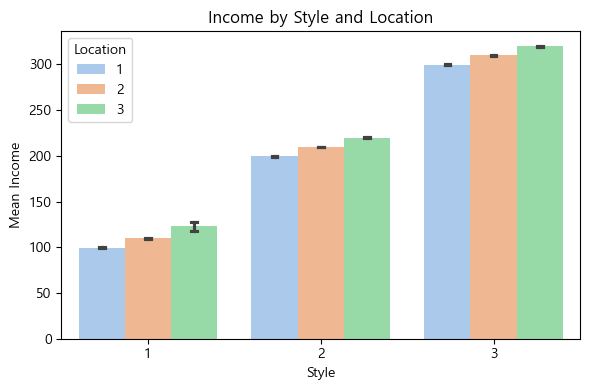

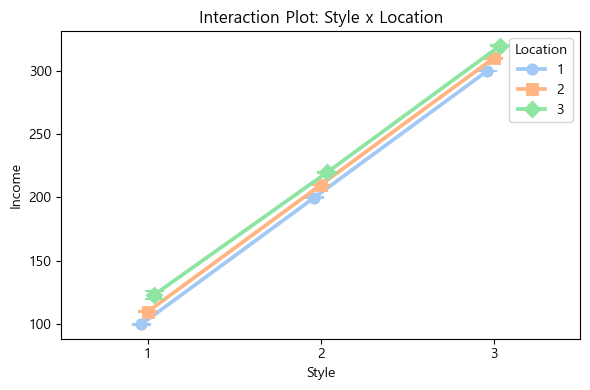

In [36]:
# Barplot: style x location 평균 + 표준편차 에러바
plt.figure(figsize=(6, 4))
sns.barplot(data=two_anova, x='style', y='income', hue='location',
            palette='pastel', capsize=0.1, errorbar='sd')
plt.title('Income by Style and Location')
plt.ylabel('Mean Income')
plt.xlabel('Style')
plt.legend(title='Location')
plt.tight_layout()
plt.show()

# Interaction plot: style x location 상호작용 패턴
plt.figure(figsize=(6, 4))
sns.pointplot(data=two_anova, x='style', y='income', hue='location',
              dodge=True, markers=['o', 's', 'D'], capsize=0.1,
              err_kws={'linewidth': 1.5}, palette='pastel')
plt.title('Interaction Plot: Style x Location')
plt.ylabel('Income')
plt.xlabel('Style')
plt.legend(title='Location')
plt.tight_layout()
plt.show()

### 2.7 사후검정 - 상호작용이 유의한 경우 (단순주효과 분석)

> pingouin 버전에 따라 p-value 컬럼명이 `p-unc`(구버전) 또는 `p_unc`(신버전, 언더바)처럼
> 다르게 나올 수 있어, 위 설정 셀에서 만든 `find_col()` 헬퍼로 실제 존재하는 컬럼명을
> 자동으로 찾아 사용합니다.

In [37]:
# 상호작용이 유의할 때는 각 style 수준별로 location에 대한 단순주효과를 검토합니다.
for s in two_anova['style'].unique():
    subset = two_anova[two_anova['style'] == s]
    print(f'\n▶▶▶ 단순 주효과: style = {s} ◀◀◀')

    simple_effect_anova = pg.anova(data=subset, dv='income', between='location', ss_type=3)
    p_col = find_col(simple_effect_anova, 'p-unc', 'p_unc')
    print('\n--- 단순 주효과 ANOVA (Location)')
    print(simple_effect_anova[['Source', 'F', p_col]].round(4))

    tukey_results = pg.pairwise_tukey(data=subset, dv='income', between='location')
    pt_col = find_col(tukey_results, 'p-tukey', 'p_tukey', 'p-corr', 'p_corr')
    print(f'\n--- 단순 주효과 Tukey HSD: style = {s}')
    print(tukey_results[['A', 'B', 'diff', pt_col]].round(4))

# 필요하다면 반대로 location 수준별 style 차이도 동일한 방식으로 확인할 수 있습니다.


▶▶▶ 단순 주효과: style = 1 ◀◀◀

--- 단순 주효과 ANOVA (Location)
     Source         F  p_unc
0  location  111.4458    0.0

--- 단순 주효과 Tukey HSD: style = 1
   A  B     diff  p_tukey
0  1  2 -10.0000      0.0
1  1  3 -23.3333      0.0
2  2  3 -13.3333      0.0

▶▶▶ 단순 주효과: style = 2 ◀◀◀

--- 단순 주효과 ANOVA (Location)
     Source       F  p_unc
0  location  2250.0    0.0

--- 단순 주효과 Tukey HSD: style = 2
   A  B  diff  p_tukey
0  1  2 -10.0      0.0
1  1  3 -20.0      0.0
2  2  3 -10.0      0.0

▶▶▶ 단순 주효과: style = 3 ◀◀◀

--- 단순 주효과 ANOVA (Location)
     Source          F  p_unc
0  location  2423.2036    0.0

--- 단순 주효과 Tukey HSD: style = 3
   A  B     diff  p_tukey
0  1  2 -10.1333      0.0
1  1  3 -20.0000      0.0
2  2  3  -9.8667      0.0


## 3. 등분산 가정 위배 시 대안

### 3.1 상호작용이 유의하지 않은 경우 (예시 데이터)

In [38]:
two_anovax = pd.read_csv(SOURCE_DIR / 'two_ANOVAx.csv')

pg.anova(data=two_anovax, dv='income', between=['style', 'location'], ss_type=3)

,Source,SS,DF,MS,F,p_unc,np2
0,style,47473.821856,2.0,23736.910928,1226.656806,7.524494e-44,0.979635
1,location,3703.914469,2.0,1851.957234,95.703942,5.458805e-18,0.789611
2,style * location,188.814915,4.0,47.203729,2.439356,5.867026e-02,0.160596
3,Residual,986.895806,51.0,19.350898,NaN,NaN,NaN


In [39]:
# 요인별 사후검정 (Scheffe)
scheffe_stylex = sph.posthoc_scheffe(two_anovax, val_col='income', group_col='style')
scheffe_locationx = sph.posthoc_scheffe(two_anovax, val_col='income', group_col='location')

print('--- style 사후검정 ---')
display(scheffe_stylex)
print('--- location 사후검정 ---')
display(scheffe_locationx)

--- style 사후검정 ---


,A,B,C
A,1.000000e+00,1.664400e-09,7.380336e-31
B,1.664400e-09,1.000000e+00,5.711897e-23
C,7.380336e-31,5.711897e-23,1.000000e+00


--- location 사후검정 ---


,L1,L2,L3
L1,1.000000,0.619722,0.037301
L2,0.619722,1.000000,0.223914
L3,0.037301,0.223914,1.000000


### 3.2 Robust ANOVA (이분산 하의 강건 회귀, HC3)

In [40]:
two_anova1 = pd.read_csv(SOURCE_DIR / 'two_ANOVA1.csv')

model = ols('income ~ C(style) * C(location)', data=two_anova1).fit()
robust_model = ols('income ~ C(style) * C(location)', data=two_anova1).fit(cov_type='HC3')

print('--- Robust ANOVA 결과 (HC3) ---')
print(robust_model.summary())

--- Robust ANOVA 결과 (HC3) ---
                            OLS Regression Results                            
Dep. Variable:                 income   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 5.296e+05
Date:                Mon, 21 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:51:56   Log-Likelihood:                -297.21
No. Observations:                 165   AIC:                             612.4
Df Residuals:                     156   BIC:                             640.4
Df Model:                           8                                         
Covariance Type:                  HC3                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------

In [41]:
# 참고: 일반적인 Type III ANOVA 결과
print('--- (참고) Type III ANOVA (일반적인 분산분석) ---')
print(sm.stats.anova_lm(model, typ=3))

--- (참고) Type III ANOVA (일반적인 분산분석) ---
                             sum_sq     df             F         PR(>F)
Intercept             169200.941176    1.0  74462.270091  6.122452e-211
C(style)              376738.319430    2.0  82897.855946  8.037911e-237
C(location)             4762.450980    2.0   1047.934216   3.675900e-91
C(style):C(location)      85.699533    4.0      9.428703   7.484412e-07
Residual                 354.479481  156.0           NaN            NaN


### 3.3 Welch's ANOVA (등분산 가정을 요구하지 않는 분산분석)

In [42]:
# pingouin
welch_anova_results = pg.welch_anova(data=two_anova1, dv='income', between='location')
welch_anova_results

,Source,ddof1,ddof2,F,p_unc,np2
0,location,2,107.766458,0.629282,0.534921,0.007806


In [43]:
# statsmodels
welch_anova_sm = anova_oneway.anova_oneway(
    data=two_anova1['income'],
    groups=two_anova1['location'],
    use_var='unequal',
    welch_correction=True,
)
print("=== Statsmodels Welch's ANOVA 결과 ===")
print(welch_anova_sm)

=== Statsmodels Welch's ANOVA 결과 ===
AnovaResult(statistic=np.float64(0.6292821087153474), pvalue=np.float64(0.5349211669615179), df=(2.0, np.float64(107.76645839117387)), df_num=2.0, df_denom=np.float64(107.76645839117387), nobs_total=np.float64(165.0), n_groups=3, means=array([206.96363636, 213.50943396, 224.22807018]), nobs=array([55., 53., 57.]), vars_=array([6976.85050505, 6526.1777939 , 6558.57205514]), use_var='unequal', welch_correction=True, df2=None, df_num2=None, pvalue2=None)


## 4. 이분산성 하의 사후분석 (Games-Howell)

### 4.1 상호작용이 유의한 경우

In [44]:
two_anova1 = pd.read_csv(SOURCE_DIR / 'two_ANOVA1.csv')

# style과 location을 결합한 그룹 변수 group_combo 생성
two_anova1['group_combo'] = two_anova1['style'].astype(str) + '_' + two_anova1['location'].astype(str)
two_anova1.head()

,No,style,location,income,group_combo
0,1,1,3,129,1_3
1,2,2,1,199,2_1
2,3,2,2,209,2_2
3,4,2,3,219,2_3
4,5,3,1,299,3_1


In [45]:
# Games-Howell 사후분석 실행 (등분산 가정 없이 사용 가능)
posthoc_results = pg.pairwise_gameshowell(data=two_anova1, dv='income', between='group_combo')
posthoc_results

,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,1_1,1_2,99.764706,109.750000,-9.985294,0.154096,-64.799045,30.776978,1.443290e-15,-22.035540
1,1_1,1_3,99.764706,123.000000,-23.235294,1.034441,-22.461680,17.360948,8.848478e-13,-7.211588
2,1_1,2_1,99.764706,199.647059,-99.882353,0.159747,-625.254280,31.555807,6.217249e-15,-209.394454
3,1_1,2_2,99.764706,209.684211,-109.919505,0.152477,-720.890305,33.976561,0.000000e+00,-234.139112
4,1_1,2_3,99.764706,219.684211,-119.919505,0.152477,-786.473780,33.976561,0.000000e+00,-255.440074
5,1_1,3_1,99.764706,299.666667,-199.901961,0.149522,-1336.941396,35.506778,0.000000e+00,-422.471367
6,1_1,3_2,99.764706,309.777778,-210.013072,0.146331,-1435.193853,32.786404,0.000000e+00,-474.571540
7,1_1,3_3,99.764706,319.650000,-219.885294,0.152379,-1443.015753,34.896116,0.000000e+00,-461.419091
8,1_2,1_3,109.750000,123.000000,-13.250000,1.035048,-12.801344,17.401010,8.385614e-09,-4.047016
9,1_2,2_1,109.750000,199.647059,-89.897059,0.163626,-549.406854,30.964215,9.436896e-15,-186.137550


In [46]:
# 유의한 조합만 필터링
alpha = 0.05
significant_pairs = posthoc_results[posthoc_results['pval'] < alpha]
significant_pairs

,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,1_1,1_2,99.764706,109.750000,-9.985294,0.154096,-64.799045,30.776978,1.443290e-15,-22.035540
1,1_1,1_3,99.764706,123.000000,-23.235294,1.034441,-22.461680,17.360948,8.848478e-13,-7.211588
2,1_1,2_1,99.764706,199.647059,-99.882353,0.159747,-625.254280,31.555807,6.217249e-15,-209.394454
3,1_1,2_2,99.764706,209.684211,-109.919505,0.152477,-720.890305,33.976561,0.000000e+00,-234.139112
4,1_1,2_3,99.764706,219.684211,-119.919505,0.152477,-786.473780,33.976561,0.000000e+00,-255.440074
5,1_1,3_1,99.764706,299.666667,-199.901961,0.149522,-1336.941396,35.506778,0.000000e+00,-422.471367
6,1_1,3_2,99.764706,309.777778,-210.013072,0.146331,-1435.193853,32.786404,0.000000e+00,-474.571540
7,1_1,3_3,99.764706,319.650000,-219.885294,0.152379,-1443.015753,34.896116,0.000000e+00,-461.419091
8,1_2,1_3,109.750000,123.000000,-13.250000,1.035048,-12.801344,17.401010,8.385614e-09,-4.047016
9,1_2,2_1,109.750000,199.647059,-89.897059,0.163626,-549.406854,30.964215,9.436896e-15,-186.137550


### 4.2 상호작용이 유의하지 않은 경우 (예시 데이터)

In [47]:
two_anovax2 = pd.read_csv(SOURCE_DIR / 'two_ANOVAx2.csv')

pg.anova(data=two_anovax2, dv='Y', between=['A', 'B'], ss_type=3)

,Source,SS,DF,MS,F,p_unc,np2
0,A,2878.975443,2,1439.487721,15.776012,8.944095e-07,0.216775
1,B,75.724898,1,75.724898,0.829904,3.642225e-01,0.007227
2,A * B,34.093589,2,17.046794,0.186824,8.298435e-01,0.003267
3,Residual,10401.969925,114,91.245350,NaN,NaN,NaN


In [48]:
# Welch's ANOVA 재실시 + Games-Howell 사후분석
print(pg.welch_anova(data=two_anovax2, dv='Y', between='A'))

posthoc_two_anovax2 = pg.pairwise_gameshowell(data=two_anovax2, dv='Y', between='A')
posthoc_two_anovax2

  Source  ddof1      ddof2          F         p_unc       np2
0      A      2  76.075878  17.626131  5.130071e-07  0.214997


,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,A1,A2,49.241878,55.731550,-6.489672,1.976635,-3.283191,72.627513,4.454728e-03,-0.727062
1,A1,A3,49.241878,61.225976,-11.984098,2.062391,-5.810778,70.286968,4.972974e-07,-1.286796
2,A2,A3,55.731550,61.225976,-5.494426,2.305669,-2.383008,77.670277,5.077613e-02,-0.527717


## 5. 시각화 모음

### 5.1 그룹별 분포 (Boxplot)

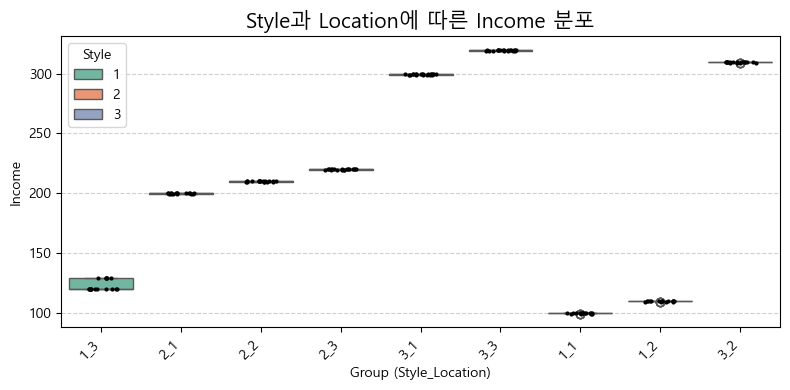

In [49]:
two_anova1 = pd.read_csv(SOURCE_DIR / 'two_ANOVA1.csv')
two_anova1['group_combo'] = two_anova1['style'].astype(str) + '_' + two_anova1['location'].astype(str)

plt.figure(figsize=(8, 4))
ax = sns.boxplot(data=two_anova1, x='group_combo', y='income', hue='style', palette='Set2')
sns.stripplot(data=two_anova1, x='group_combo', y='income', color='black', size=3, jitter=0.2, ax=ax)

plt.title('Style과 Location에 따른 Income 분포', fontsize=15)
plt.xlabel('Group (Style_Location)')
plt.ylabel('Income')
plt.legend(title='Style')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 5.2 상호작용 플롯 (Interaction Plot)

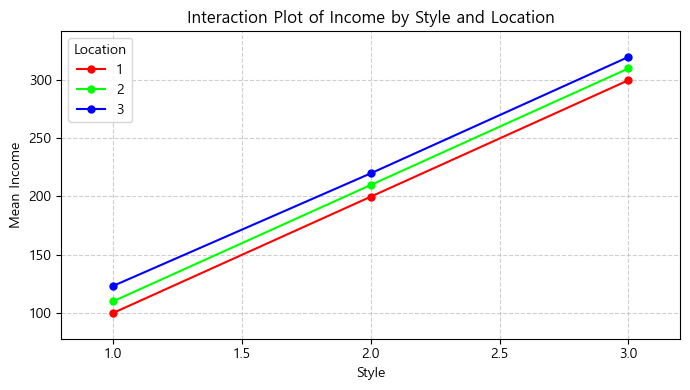

In [50]:
two_anova1['style'] = two_anova1['style'].astype('category')
two_anova1['location'] = two_anova1['location'].astype('category')

fig, ax = plt.subplots(figsize=(7, 4))
interaction_plot(
    x=two_anova1['style'],
    trace=two_anova1['location'],
    response=two_anova1['income'],
    ax=ax,
    ms=10,
)
ax.set_title('Interaction Plot of Income by Style and Location')
ax.set_xlabel('Style')
ax.set_ylabel('Mean Income')
ax.legend(title='Location')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 5.3 잔차 진단 플롯 (등분산성 / 정규성 확인)

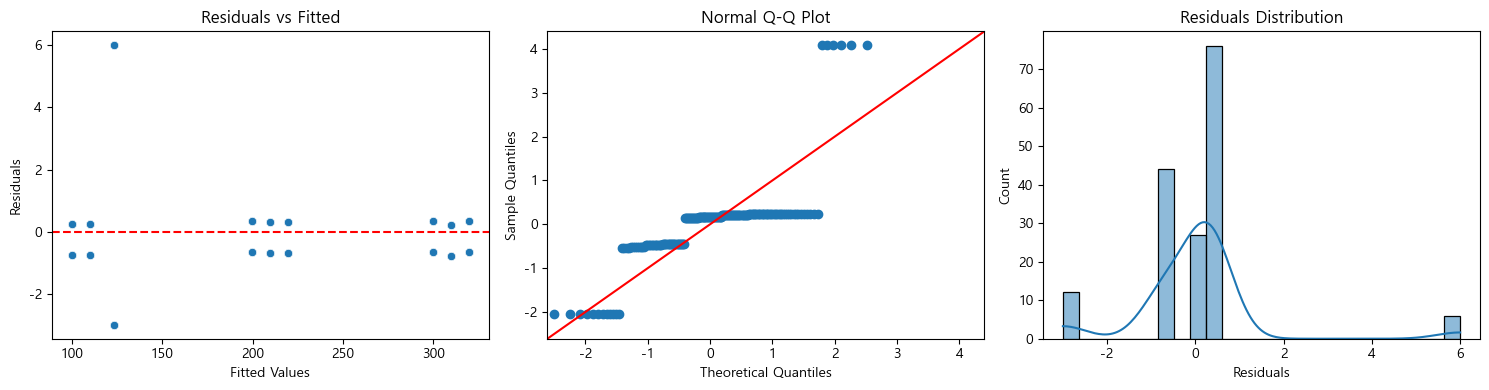

In [51]:
model = ols('income ~ C(style) * C(location)', data=two_anova1).fit()
residuals = model.resid
fitted = model.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 잔차 vs 적합값 (등분산성 확인)
sns.scatterplot(x=fitted, y=residuals, ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals vs Fitted')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')

# Q-Q 플롯 (정규성 확인)
sm.qqplot(residuals, line='45', fit=True, ax=axes[1])
axes[1].set_title('Normal Q-Q Plot')

# 잔차 히스토그램
sns.histplot(residuals, kde=True, ax=axes[2])
axes[2].set_title('Residuals Distribution')
axes[2].set_xlabel('Residuals')

plt.tight_layout()
plt.show()

### 5.4 그룹별 평균 비교 (Bar + Error, Violin Plot)

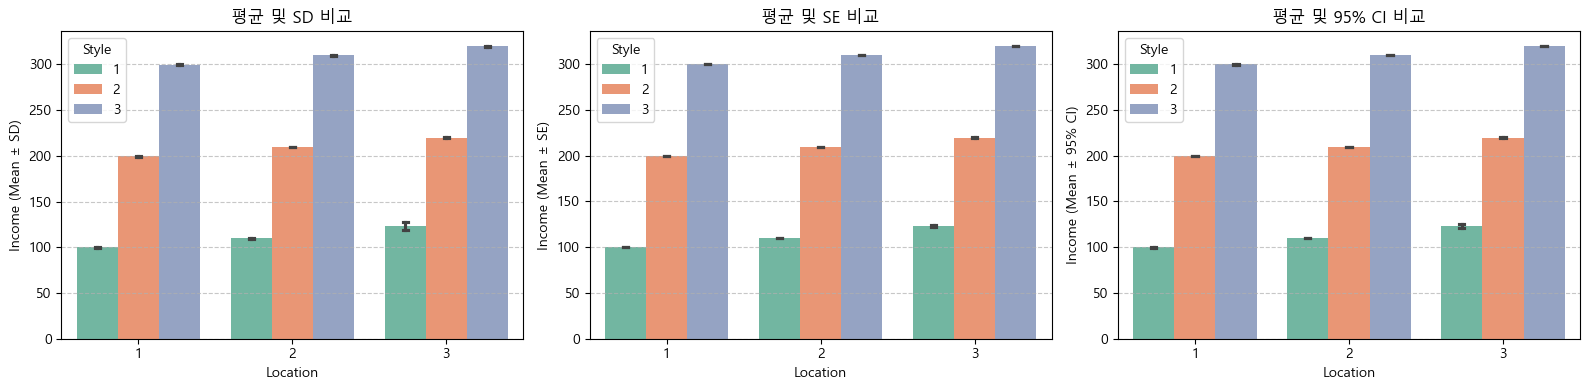

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, errorbar_type, label in zip(axes, ['sd', 'se', 'ci'], ['SD', 'SE', '95% CI']):
    sns.barplot(x='location', y='income', hue='style', data=two_anova1,
                errorbar=errorbar_type, palette='Set2', capsize=0.1, ax=ax)
    ax.set_title(f'평균 및 {label} 비교')
    ax.set_xlabel('Location')
    ax.set_ylabel(f'Income (Mean ± {label})')
    ax.legend(title='Style')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

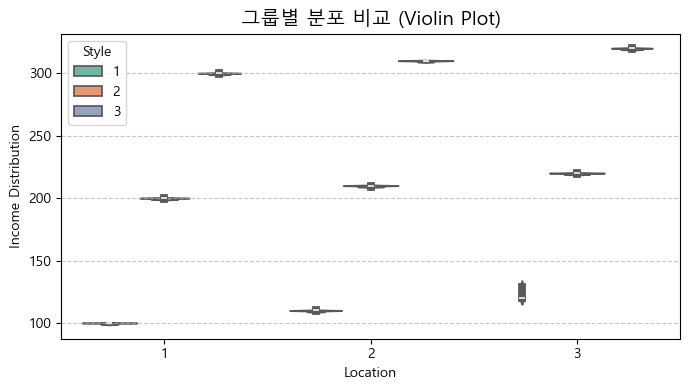

In [53]:
plt.figure(figsize=(7, 4))
sns.violinplot(x='location', y='income', hue='style', data=two_anova1, palette='Set2')
plt.title('그룹별 분포 비교 (Violin Plot)', fontsize=14)
plt.xlabel('Location')
plt.ylabel('Income Distribution')
plt.legend(title='Style')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 5.5 사후검정 결과 시각화 (Games-Howell)

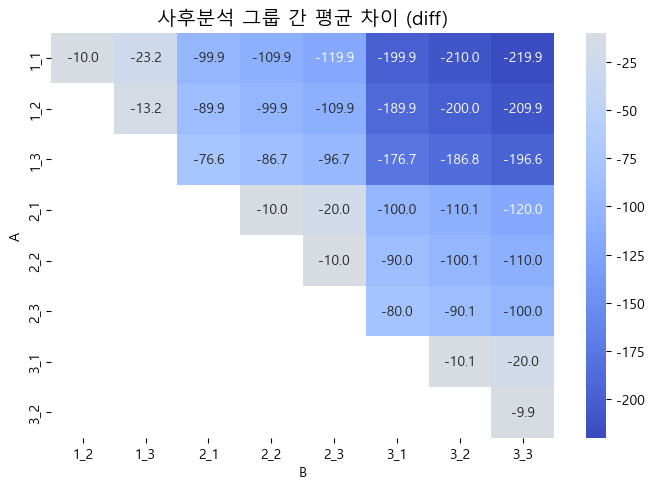

In [54]:
posthoc_results = pg.pairwise_gameshowell(data=two_anova1, dv='income', between='group_combo')

# 그룹 간 평균 차이 히트맵
heat_data = posthoc_results.pivot(index='A', columns='B', values='diff')

plt.figure(figsize=(7, 5))
sns.heatmap(heat_data, annot=True, fmt='.1f', cmap='coolwarm', center=0)
plt.title('사후분석 그룹 간 평균 차이 (diff)', fontsize=14)
plt.tight_layout()
plt.show()

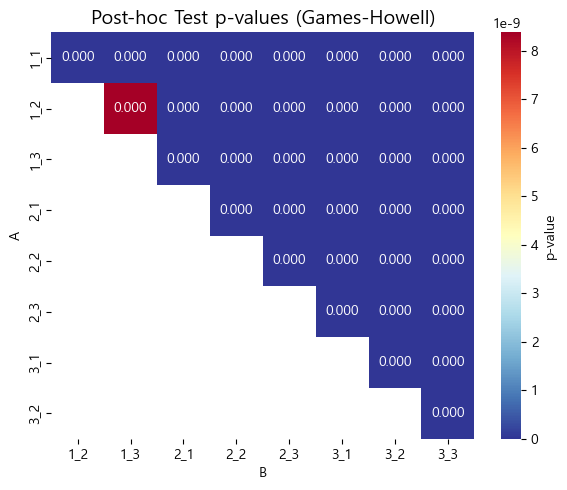

In [55]:
# p-value 히트맵
piv = posthoc_results.pivot(index='A', columns='B', values='pval')

plt.figure(figsize=(6, 5))
sns.heatmap(piv, annot=True, cmap='RdYlBu_r', fmt='.3f', cbar_kws={'label': 'p-value'})
plt.title('Post-hoc Test p-values (Games-Howell)', fontsize=14)
plt.tight_layout()
plt.show()

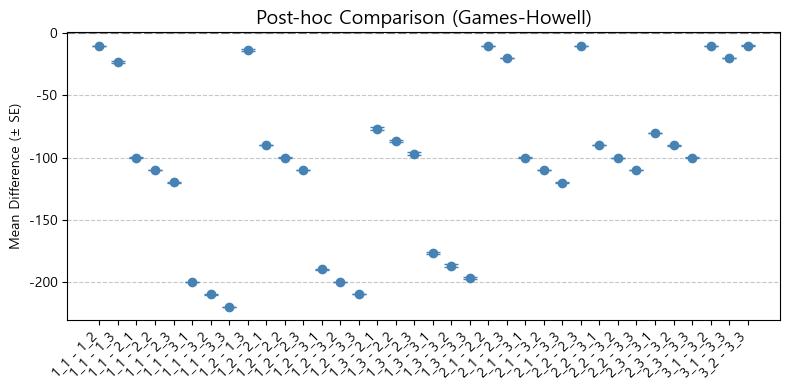

In [56]:
# 평균 차이(diff) ± 표준오차(se) 플롯
plt.figure(figsize=(8, 4))
plt.errorbar(
    x=range(len(posthoc_results)),
    y=posthoc_results['diff'],
    yerr=posthoc_results['se'],
    fmt='o', capsize=5, color='steelblue',
)
plt.axhline(0, color='gray', linestyle='--')

labels = posthoc_results['A'].astype(str) + ' - ' + posthoc_results['B'].astype(str)
plt.xticks(range(len(posthoc_results)), labels, rotation=45, ha='right')

plt.ylabel('Mean Difference (± SE)')
plt.title('Post-hoc Comparison (Games-Howell)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 6. 평균 비교표에 사후검정 그룹 표시 — CLD(a, b, c) 표기

원본 노트북에는 "scikit-posthocs를 사용한 CLD(Compact Letter Display) 최종 코드"라는
제목만 있고 실제 코드는 비어 있었습니다. 아래는 사후검정 p-value 행렬을 이용해
같은 문자를 공유하는 집단끼리는 통계적으로 유의한 차이가 없음을 나타내는
간단한 CLD를 생성하는 예시 코드입니다.

> 아래 알고리즘은 교육용으로 작성한 단순 탐욕(greedy) 알고리즘이며,
> R의 `multcompView` 패키지처럼 엄밀하게 최소 문자 수를 보장하지는 않습니다.
> 정식 보고서에 사용할 때는 결과를 반드시 눈으로 다시 확인이 필요합니다.

In [57]:
import string

def get_cld(pvalue_matrix: pd.DataFrame, alpha: float = 0.05) -> pd.DataFrame:
    """사후검정 p-value 행렬(symmetric)로부터 간단한 CLD(a, b, c ...) 문자를 생성합니다.

    Parameters
    ----------
    pvalue_matrix : 정사각형 DataFrame. index/columns가 그룹명이며,
                     원소는 두 그룹 간 사후검정 p-value.
    alpha : 유의수준

    Returns
    -------
    DataFrame(columns=['group', 'cld'])
    """
    groups = sorted(pvalue_matrix.index.astype(str), key=lambda x: str(x))
    remaining = groups.copy()
    letters = {g: '' for g in groups}
    letter_idx = 0

    def not_significant(g1, g2):
        return pvalue_matrix.loc[g1, g2] >= alpha

    while remaining:
        letter = string.ascii_lowercase[letter_idx]
        base = remaining[0]
        same_group = [base]
        for g in remaining[1:]:
            if all(not_significant(g, m) for m in same_group):
                same_group.append(g)
        for g in same_group:
            letters[g] += letter
        remaining = [g for g in remaining if g not in same_group]
        letter_idx += 1

    return pd.DataFrame({'group': groups, 'cld': [letters[g] for g in groups]})


# 예시: 일원분산분석(conv 별 satis) Scheffe 사후검정 결과를 CLD로 표시
scheffe = sph.posthoc_scheffe(one_anova, val_col='satis', group_col='conv')
scheffe.index = scheffe.columns = scheffe.columns.astype(str)

cld_table = get_cld(scheffe, alpha=0.05)

mean_table = one_anova.groupby('conv')['satis'].mean().reset_index()
mean_table['conv'] = mean_table['conv'].astype(str)

summary = mean_table.merge(cld_table, left_on='conv', right_on='group').drop(columns='group')
summary

,conv,satis,cld
0,1,2.625000,a
1,2,3.676471,a
2,3,3.625000,a
3,4,3.594937,a
4,5,4.538462,b
